## Bar chart of high-level reversion reasons

In [1]:
# assert statement
# require statement
# if-based revert statement (implied by the existance of both "if " and "revert" in the same line.)


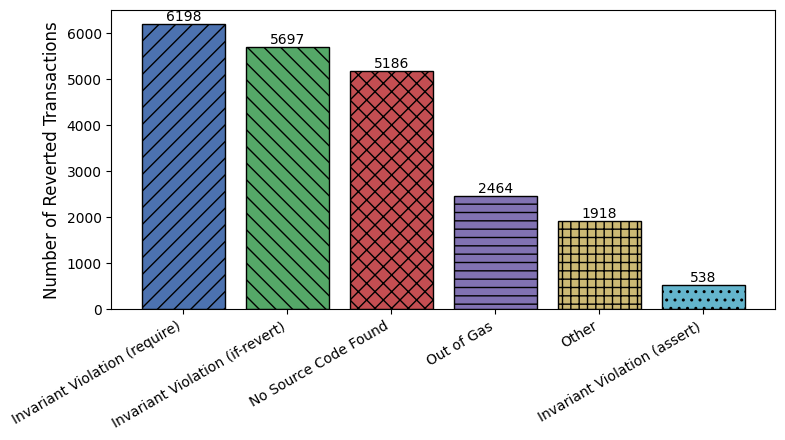

In [3]:
dataset_file = '../main.log'
import matplotlib.pyplot as plt
from collections import Counter

# Load and parse the log file
with open(dataset_file, "r") as file:
    lines = file.readlines()

# Categorize reasons
reason_counts = Counter()

for line in lines:
    if 'invariant:' not in line:
        continue
    reason_part = line.split("invariant: ")[1].strip().lower()

    if "out of gas" in reason_part:
        reason_counts["Out of Gas"] += 1
    elif "no source code found" in reason_part:
        reason_counts["No Source Code Found"] += 1
    elif "assert" in reason_part:
        reason_counts["Invariant Violation (assert)"] += 1
    elif "require" in reason_part:
        reason_counts["Invariant Violation (require)"] += 1
    elif "if " in reason_part and "revert" in reason_part:
        reason_counts["Invariant Violation (if-revert)"] += 1
    else:
        reason_counts["Other"] += 1

# Sort reasons by count in descending order
sorted_items = sorted(reason_counts.items(), key=lambda x: x[1], reverse=True)
sorted_labels = [item[0] for item in sorted_items]
sorted_counts = [item[1] for item in sorted_items]

# Define color palette and hatch patterns (extend if needed)
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
hatches = ['//', '\\\\', 'xx', '--', '++', '..']

# Pad color/hatch list if more categories exist
while len(colors) < len(sorted_labels):
    colors.extend(colors)
    hatches.extend(hatches)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor='white')
bars = ax.bar(sorted_labels, sorted_counts, color=colors[:len(sorted_labels)], edgecolor='black')

# Apply hatch patterns
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Annotate values
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height}', ha='center', va='bottom', fontsize=10)

# Label formatting
ax.set_ylabel("Number of Reverted Transactions", fontsize=12)
ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=30, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# White background with no gridlines
ax.grid(False)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Save and show
plt.tight_layout()
plt.savefig("reversion_reasons_bar_chart_sorted.pdf", bbox_inches='tight')
plt.show()
